In [ ]:
# ĐỀ THI THỬ THỰC HÀNH NHẬP MÔN XỬ LÝ ẢNH SỐ

## 1. Cài đặt thư viện

In [1]:
!pip install imageio scipy scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 814.4 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]


## Câu 1: Cho ảnh có tên là a.jpg và thực hiện các yêu cầu

### Viết chương trình sử dụng mean filter cho ảnh

[[ 98 101 105 ...  92  95  99]
 [ 97 100 105 ...  85  88  91]
 [ 96  99 104 ...  79  82  85]
 ...
 [ 46  34  38 ...  61  63  65]
 [ 47  35  39 ...  62  66  68]
 [ 49  36  39 ...  63  68  71]]
[[ 99 101 103 ...  87  89  90]
 [ 99 101 103 ...  85  87  88]
 [ 99 101 104 ...  82  83  84]
 ...
 [ 39  41  40 ...  60  62  64]
 [ 40  42  41 ...  61  64  65]
 [ 40  43  41 ...  62  64  66]]


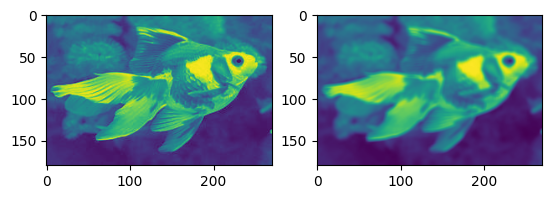

In [3]:
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as sn
import matplotlib.pylab as plt
import colorsys

#đọc ảnh và chuyển sang ảnh xám
a = iio.imread('a.jpg', mode ='L')
# mean filter (bộ lọc trung bình)
#Khởi tạo bộ lọc trung bình 5x5  mỗi phần tử có giá trị 1/25.
k= np.ones((5,5))/25
# thực hiện phép tính và lưu ảnh mới
b = sn.convolve (a, k).astype(np.uint8)
iio.imsave('a_mean_filter.jpg', b)
print(a)
print (b)
plt.subplot(1,2,1)
plt.imshow(a)
plt.subplot(1,2,2)
plt.imshow(b)
plt.show ()

### Viết chương trình sử dụng filter xác định biên của ảnh trên

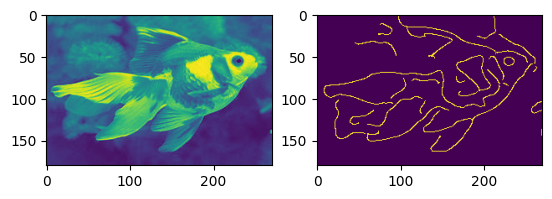

In [6]:
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as sn
from skimage import feature
import matplotlib.pylab as plt
import colorsys
# opening the image and converting it to grayscale
a = iio.imread('a.jpg', mode='L')
b = feature.canny(a, sigma=3).astype(np.uint8)
iio.imsave('a_canny filter_edge detection.png', b)

plt.subplot(1,2,1)
plt.imshow(a)
plt.subplot(1,2,2)
plt.imshow(b)
plt.show ()

### Viết chương trình đổi màu ảnh từ không gian màu BGR sang một màu ngẫu nhiên (RGB) bằng cách thay đổi các kênh màu một cách ngẫu nhiên, sau đó lưu hình mới vào file a_random_color.jpg

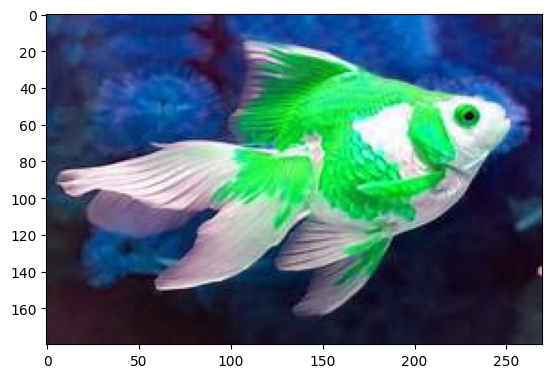

In [32]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
data = iio.imread('a.jpg')
R, G, B = 0, 1, 2
channels = [R, G, B]
np.random.shuffle(channels)
random_color_data = data[:, :, channels]
plt.imshow(random_color_data)
plt.show()


### Chuyển ảnh sang không gian màu HSV và tách riêng kênh Hue, Saturation, Value để  lưu  thành  ba  ảnh  grayscale  tương  ứng  (a_hue.jpg,  a_saturation.jpg, a_value.jpg)

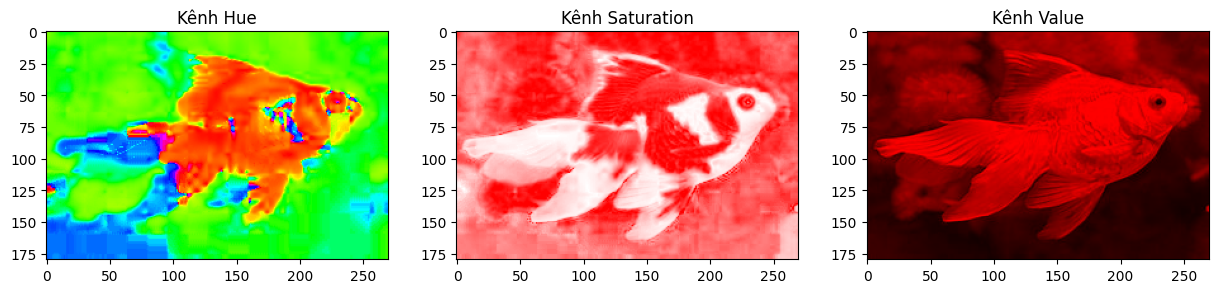

In [ ]:
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt
import colorsys
img = iio.imread('a.jpg')  
rgb2hsv = np.vectorize(colorsys.rgb_to_hsv)
h, s, v = rgb2hsv(img[:, :, 0]/255, img[:, :, 1]/255, img[:, :, 2]/255)
h_img = np.vectorize(colorsys.hsv_to_rgb)(h, np.ones_like(s), np.ones_like(v))
h_img = (np.array(h_img).transpose((1, 2, 0)) * 255).astype(np.uint8)
s_img = np.vectorize(colorsys.hsv_to_rgb)(np.zeros_like(h), s, np.ones_like(v))
s_img = (np.array(s_img).transpose((1, 2, 0)) * 255).astype(np.uint8)
v_img = np.vectorize(colorsys.hsv_to_rgb)(np.zeros_like(h), np.ones_like(s), v)
v_img = (np.array(v_img).transpose((1, 2, 0)) * 255).astype(np.uint8)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(h_img)
plt.title("Kênh Hue")
plt.subplot(1, 3, 2)
plt.imshow(s_img)
plt.title("Kênh Saturation")
plt.subplot(1, 3, 3)
plt.imshow(v_img)
plt.title("Kênh Value")
plt.show()
iio.imwrite('a_hue.jpg', h_img)
iio.imwrite('a_saturation.jpg', s_img)
iio.imwrite('a_value.jpg', v_img)

## Câu 2: Viết một chương trình Python sử dụng OpenCV để tạo menu động cho phép người dùng chọn các phương pháp biến đổi ảnh từ một danh sách mở rộng, áp dụng cho nhiều ảnh cùng lúc, và thực hiện các phân tích bổ sung. Các yêu cầu cụ thể

### 1. Tạo một menu động cho phép người dùng chọn các phương pháp biến đổi ảnh sau:  
- Image inverse transformation(0.5 Điểm) 
- Gamma-Correction (với giá trị gamma ngẫu nhiên từ 0.5 đến 2.0) (0.5 Điểm) 
- Log Transformation (với hệ số nhân ngẫu nhiên từ 1.0 đến 5.0) (0.5 Điểm) 
- Histogram equalization(0.5 Điểm) 
- Contrast Stretching (tùy chỉnh với giá trị min và max ngẫu nhiên từ 0 đến 255) 
(0.5 Điểm) 
- Adaptive Histogram Equalization (sử dụng CLAHE với ô lưới 8x8)

### 2. Chương trình phải xử lý đồng thời ba ảnh đầu vào có tên image1.jpg, image2.jpg, và image3.jpg

### 3. Khi người dùng nhấn các phím sau, chương trình sẽ thực hiện biến đổi tương ứng trên cả ba ảnh 
- Phím I: Image inverse transformation  
- Phím G: Gamma-Correction  
- Phím L: Log Transformation  
- Phím H: Histogram equalization  
- Phím C: Contrast Stretching  
- Phím A: Adaptive Histogram Equalization

### 4. Đối với mỗi biến đổi, lưu kết quả của từng ảnh vào các file riêng biệt với tên định dạng  output_[phương  pháp]_[số  ảnh].jpg  (ví  dụ:  output_inverse_1.jpg, output_gamma_2.jpg).

Chọn phương pháp biến đổi ảnh:
I - Image Inverse
G - Gamma Correction
L - Log Transformation
H - Histogram Equalization
C - Contrast Stretching
A - Adaptive Histogram Equaliztion


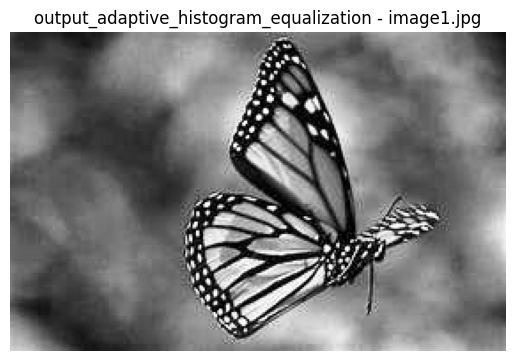

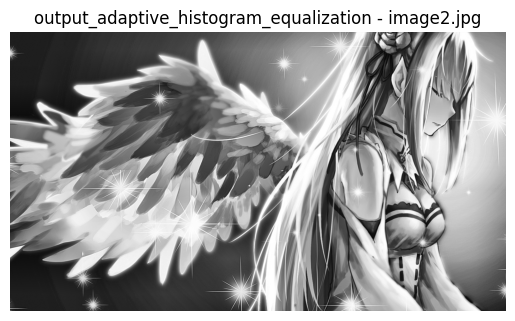

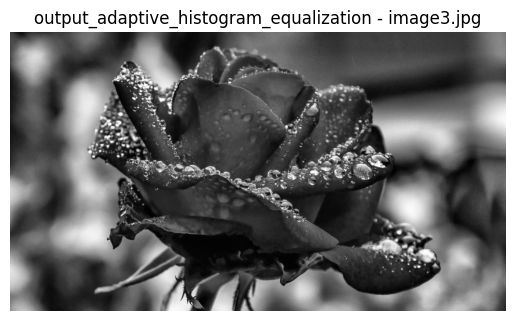

In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
image_filenames = ["image1.jpg", "image2.jpg", "image3.jpg"]
os.makedirs("output", exist_ok=True)
def read_gray_image(filename):
    path = os.path.join(filename)
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)
def image_inverse(img):
    return 255 - img
def gamma_correction(img, gamma=2.2):
    normalized = img / 255.0
    corrected = np.power(normalized, gamma)
    return np.uint8(corrected * 255)
def log_transformation(img):
    c = 255 / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img.astype(np.float32))
    return np.uint8(log_img)
def histogram_equalization(img):
    return cv2.equalizeHist(img)
def contrast_stretch(img):
    a, b = np.min(img), np.max(img)
    stretched = ((img - a) * 255 / (b - a)).astype(np.uint8)
    return stretched
def adaptive_histogram_equalization(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(img)
def show_and_save(img, original_filename, method_name):
    new_name = f"{method_name}_{original_filename}"
    output_path = os.path.join("output", new_name)
    cv2.imwrite(output_path, img)
    plt.imshow(img, cmap='gray')
    plt.title(f"{method_name} - {original_filename}")
    plt.axis('off')
    plt.show()
print("Chọn phương pháp biến đổi ảnh:")
print("I - Image Inverse")
print("G - Gamma Correction")
print("L - Log Transformation")
print("H - Histogram Equalization")
print("C - Contrast Stretching")
print("A - Adaptive Histogram Equaliztion")
choice = input("Nhập lựa chọn (I/G/L/H/C/A): ").strip().upper()
if choice == 'G':
    try:
        gamma_value = float(input("Nhập giá trị gamma: "))
    except ValueError:
        print("Giá trị gamma không hợp lệ, dùng mặc định 2.2")
        gamma_value = 2.2
for filename in image_filenames:
    img = read_gray_image(filename)
    if img is None:
        print(f"Lỗi: Không đọc được ảnh {filename}")
        continue
    if choice == 'I':
        result = image_inverse(img)
        show_and_save(result, filename, "output_inverse")
    elif choice == 'G':
        result = gamma_correction(img, gamma=gamma_value)
        show_and_save(result, filename, f"output_gamma_{gamma_value}")
    elif choice == 'L':
        result = log_transformation(img)
        show_and_save(result, filename, "output_log_transformation")
    elif choice == 'H':
        result = histogram_equalization(img)
        show_and_save(result, filename, "output_histogram_equalization")
    elif choice == 'C':
        result = contrast_stretch(img)
        show_and_save(result, filename, "output_contrast_streching")
    elif choice == 'A':
        result = adaptive_histogram_equalization(img)
        show_and_save(result, filename, "output_adaptive_histogram_equalization")
    else:
        print("Lựa chọn không hợp lệ!")

## Câu 3: Viết một chương trình Python sử dụng OpenCV để xử lý ba ảnh: colorful-ripe-tropical-fruits.jpg,  quang-ninh.jpg,  và  pagoda.jpg  với  các  phương  pháp biến đổi và tiền xử lý nâng cao.

### Tăng kích thước ảnh colorful-ripe-tropical-fruits.jpg thêm 30 pixel ở cả chiều rộng và chiều cao

(1414, 2119, 3)
(1444, 2149, 3)


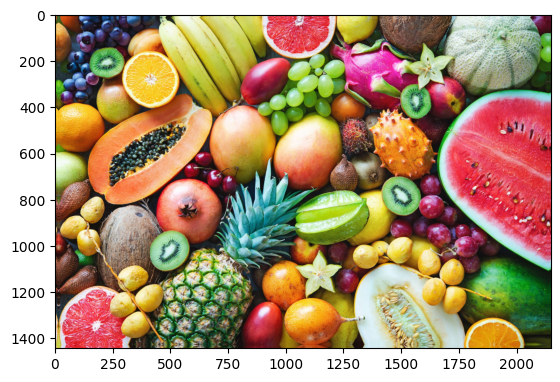

In [1]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('colorful-ripe-tropical-fruits.jpg')
print(data.shape)
padded = np.pad(data, ((15, 15), (15, 15), (0, 0)), mode='reflect')
print(padded.shape)
plt.imshow(padded)
plt.show()


### Xoay ảnh quang-ninh.jpg 45 độ theo chiều kim đồng hồ và lật ngang

(605, 1021, 3)


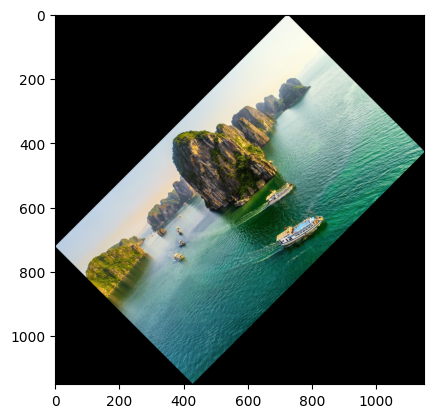

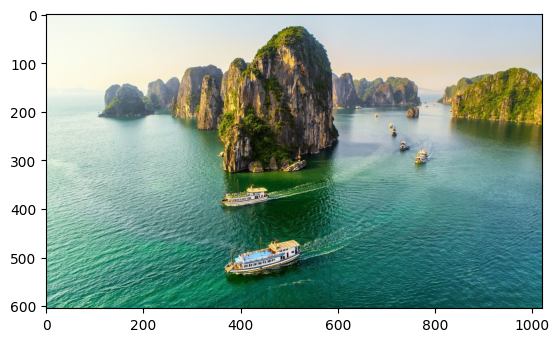

In [7]:
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('quang_ninh.jpg')
print(data.shape)
d1 = nd.rotate(data, 45)
plt.imshow(d1)
plt.show()
flipped = np.fliplr(data)  
plt.imshow(flipped)

### Tăng kích thước ảnh pagoda.jpg lên 5 lần và áp dụng Gaussian blur với kernel 7x7 để làm mịn.

(348, 600, 3)
(1740, 3000, 3)


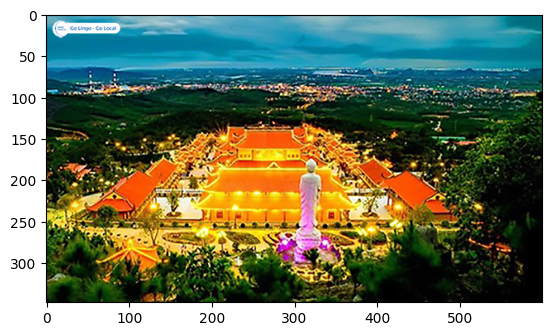

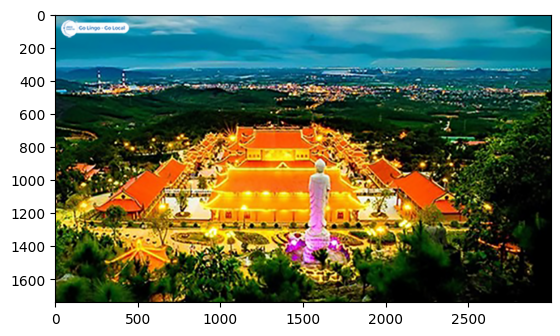

In [17]:
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pylab as plt
data = iio.imread('pagoda.jpg')
print(data.shape)
bdata = nd.zoom(data, (5, 5, 1))
print(bdata.shape)
plt.imshow(data)
plt.show()
blurred = nd.gaussian_filter(bdata, sigma=(1.1, 1.1, 0))
plt.imshow(blurred)


### Ứng dụng công thức bên dưới cho ảnh pagoda.jpg
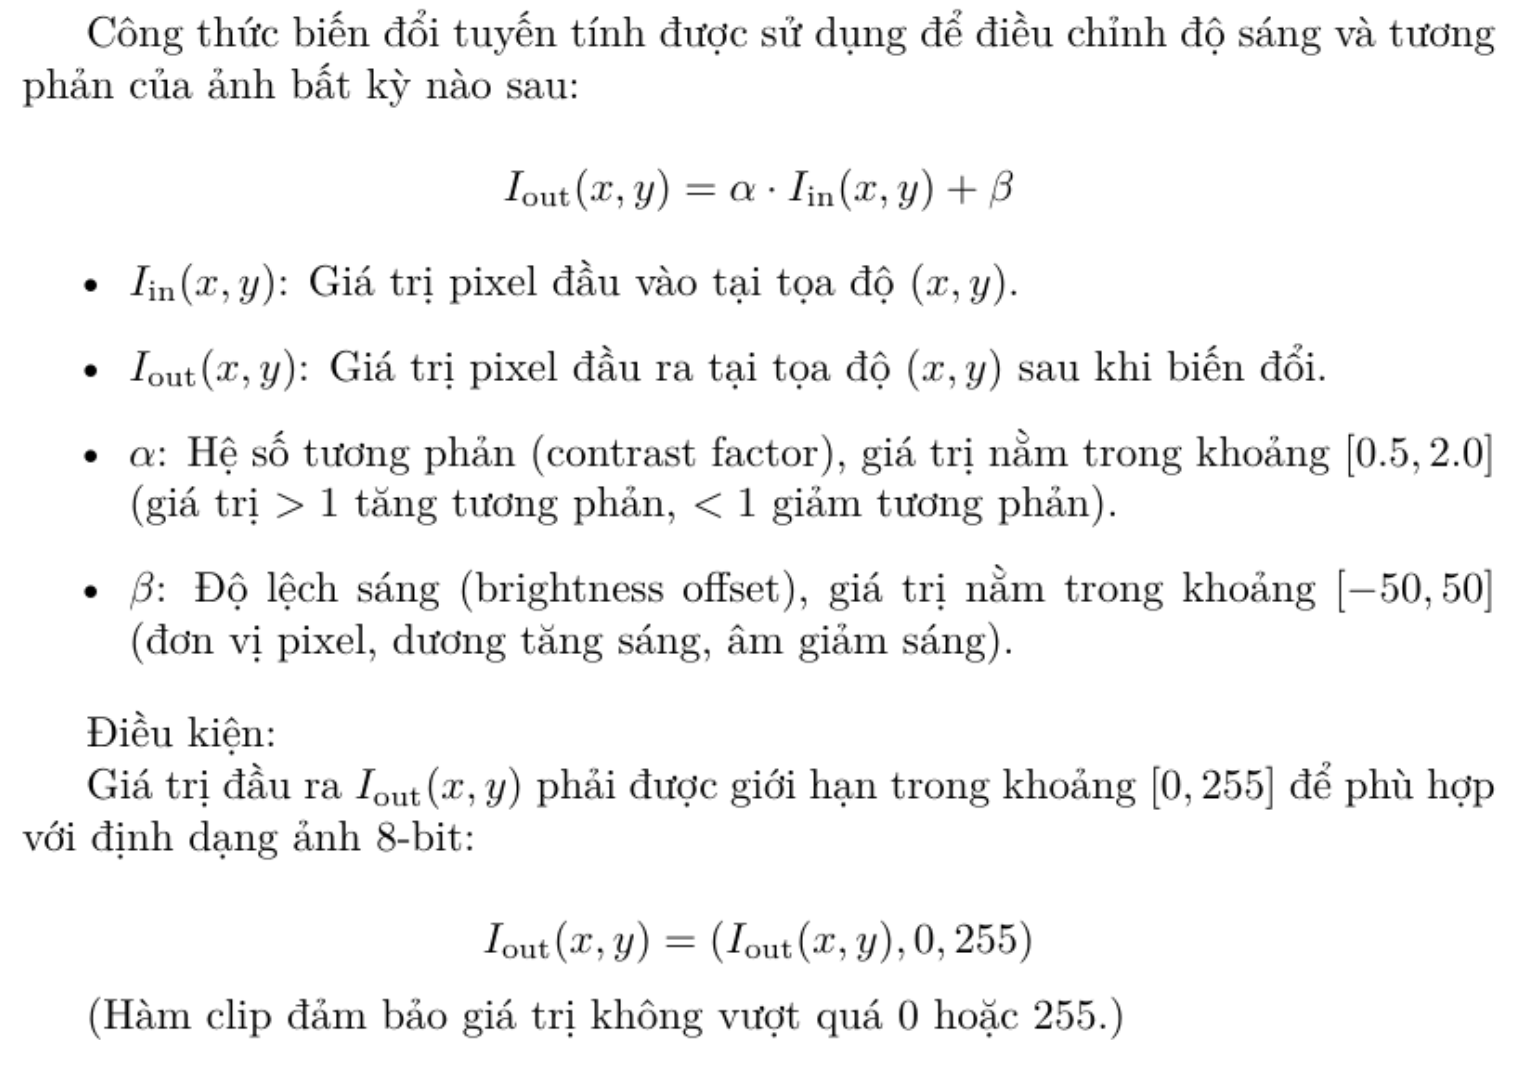

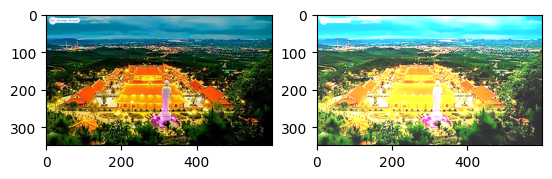

In [18]:
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
import matplotlib.pyplot as plt
data = iio.imread('pagoda.jpg')
alpha = float(input("Nhập vào giá trị alpha: "))
beta = float(input("Nhập vào giá trị beta: ")) 
if not (0.5 <= alpha <= 2.0):
    raise ValueError("alpha phải nằm trong khoảng [0.5, 2.0]")
if not (-50 <= beta <= 50):
    raise ValueError("beta phải nằm trong khoảng [-50, 50]")
adjusted = np.clip(alpha * data + beta, 0, 255).astype(np.uint8)
plt.subplot(1, 2, 1)
plt.imshow(data)
plt.subplot(1, 2, 2)
plt.imshow(adjusted)
plt.show()
